<a href="https://colab.research.google.com/github/BridgingAISocietySummerSchools/Python-for-Data-Science-Workshop/blob/main/02_advanced_self_learning/14_capstone_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏆 Notebook 14 — Capstone: A Venue Decision from Weather Data

> **Advanced & Self-Learning Track — Notebook 14 of 14 (Capstone)** · **Estimated time:** 75–105 min · **Difficulty:** Intermediate · **Prerequisites:** Notebooks 01–13 (most recently [`13_pytorch_basics.ipynb`](13_pytorch_basics.ipynb))

This track is the self-paced deep-dive of the course; the 90-minute live **Introduction Session** lives in `01_introduction/`.

This is your **integration project**, and it is deliberately not a lesson. There is a client, a question, two constraints and a deliverable. You will use *everything* from the previous thirteen notebooks: variables, control flow and collections (01–04), functions (05), NumPy (06), pandas (07), the cleaning and feature-engineering habits (08), matplotlib (09), the exploratory routine (10), the machine-learning vocabulary (11) and the scikit-learn workflow (12) — with the hand-written training loop of notebook 13 waiting for whatever you build after this.

## 🎯 Learning objectives

1. **Read a brief** and turn someone else's requirements into a question the data can answer.
2. **Audit** the dataset with the notebook-08 sanity habits before trusting a single number.
3. **Explore** it with the notebook-10 checklist — including the step almost everyone skips.
4. **Visualise** the findings as a four-panel dashboard where every panel states a claim.
5. **Model** temperature against rainfall, and say honestly what the model can and cannot support.
6. **Decide**, and write the five-bullet executive summary the client actually asked for.

By the end you should be able to hand a non-analyst a defensible recommendation, the numbers behind it, and an honest list of what your data cannot tell them. That last item is the professional part.

## 🧰 Tools you will use

- pandas DataFrames, `groupby` and `pivot_table` — notebook 07
- data sanity checks and categorical feature engineering — notebook 08
- NumPy arrays — notebook 06
- matplotlib for the 2×2 dashboard and the decision chart — notebook 09
- the explore-before-you-conclude discipline of EDA, checklist step 6 in particular — notebook 10
- the ML vocabulary of features, target and fit/predict — notebook 11
- scikit-learn `LinearRegression` and `RandomForestRegressor` — notebook 12
- f-strings everywhere — notebook 01

(Deep learning stays out of this project on purpose: notebook 13's PyTorch training loop is a different tool for a different kind of problem. 60 rows of weather data is a job for a linear model.)

⬅️ **Previous:** [`13_pytorch_basics.ipynb`](13_pytorch_basics.ipynb)

## 1. The brief

Read this once, then keep it in view. Everything below exists to answer it.

> **From:** Operations, Bridging AI & Society Summer Schools
> **To:** you, the data person
> **Subject:** US venue for the July residential school
>
> We are placing a two-week residential summer school in the **United States, in July**. Five cities are on the shortlist: **New York, Los Angeles, Chicago, Miami, Seattle**. The venue team has two hard constraints:
>
> - **Mean daily temperature between 18 °C and 27 °C.** The lecture rooms have no air conditioning, and below 18 °C the outdoor sessions stop working.
> - **Monthly rainfall under 90 mm.** Half the social programme is outdoors.
>
> Please send back **one recommended city**, the numbers that justify it, and an honest statement of what your data *cannot* tell us. Five bullets. We read these on our phones.

That is the whole project: two constraints, one recommendation, one honest caveat — and a year of monthly weather data to get there.

**Why not just look the answer up?** Because the point is the route. A decision you can defend has the numbers attached *and* the traps you nearly fell into documented. You will fall into at least one on the way. That is arranged.

## 2. Setup

> 🎨 The chart colours in this notebook follow the [Bridging AI & Society](https://bridgingaiandsociety.org) summer-school brand palette, defined once in the setup cell below.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize"   : (8, 5),
    "axes.grid"        : True,
    "grid.alpha"       : 0.3,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "font.size"        : 11,
})

# --- Bridging AI & Society course plot style -------------------------------
BAS_BLUE = "#416bcc"   # brand accent (lapis blue) — primary series
BAS_INK  = "#1c2025"   # brand ink — text/edges where needed
# supporting colours, chosen to sit well next to the lapis accent:
BAS_AMBER  = "#d9822b"   # secondary series / contrast
BAS_GREEN  = "#3a9e6e"   # "good" / positive
BAS_RED    = "#c8504f"   # "bad" / warnings / errors
BAS_PURPLE = "#7a5fb5"   # tertiary series
BAS_GREY   = "#8a919c"   # de-emphasised / reference lines
BAS_PALETTE = [BAS_BLUE, BAS_AMBER, BAS_GREEN, BAS_RED, BAS_PURPLE, BAS_GREY]

plt.rcParams["axes.prop_cycle"] = plt.cycler(color=BAS_PALETTE)
# ---------------------------------------------------------------------------

print(f"pandas {pd.__version__}, numpy {np.__version__}")

pandas 2.3.3, numpy 2.0.2


## 3. The data

In a real project you would load a CSV with `pd.read_csv("weather.csv")`, or pull station records from an API. Here we **simulate** a year so the notebook is fully self-contained and reproducible: realistic monthly climatology per city, plus a little noise.

Be honest with yourself about what that means. Simulated data makes this a **rehearsal of the decision, not the decision** — and "the data is simulated" has to appear in the caveat we send back to Ops. Everything else about the workflow is real.

Each row is one **(city, month)** observation:

| Column          | Meaning                                              |
|-----------------|------------------------------------------------------|
| `city`          | one of the 5 shortlisted US cities                   |
| `month`, `month_num` | Jan, Feb, …, Dec  +  1–12                       |
| `temperature`   | mean daily °C for that month                          |
| `precipitation` | total mm of rain/snow for that month                  |
| `humidity`      | average % relative humidity                           |
| `wind`          | average km/h wind speed                               |

Note the generator is wrapped in a **function** with a `seed` argument (notebook 05). That is not decoration: in Exercise 14.3 you will re-run it with other seeds to find out how fragile your recommendation is.

In [2]:
cities = ["New York", "Los Angeles", "Chicago", "Miami", "Seattle"]
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Realistic monthly mean temperatures (°C) for each city
city_temps = {
    "New York":    [ 0,  2,  7, 13, 18, 23, 26, 25, 21, 15,  9,  3],
    "Los Angeles": [14, 14, 15, 17, 18, 20, 22, 23, 22, 19, 16, 14],
    "Chicago":     [-4, -2,  3, 10, 16, 22, 25, 24, 19, 12,  4, -2],
    "Miami":       [20, 21, 23, 25, 27, 28, 29, 29, 28, 26, 23, 21],
    "Seattle":     [ 5,  7,  9, 11, 14, 17, 20, 20, 17, 12,  8,  5],
}

# Average monthly precipitation (mm) per city
city_precip = {
    "New York":    [85, 75, 95, 100, 110, 95, 110, 100, 95, 85, 90, 90],
    "Los Angeles": [80, 90, 60, 25,   5,  2,   1,  2, 10, 20, 35, 60],
    "Chicago":     [50, 50, 70, 90,  100, 110, 95, 110, 85, 75, 65, 60],
    "Miami":       [50, 50, 55, 80,  130, 230, 165, 215, 230, 165, 80, 50],
    "Seattle":     [140,95,90, 75,   50,  40,  20, 25, 45, 90, 155, 145],
}


def make_weather(seed: int = 42) -> pd.DataFrame:
    """Simulate one year of monthly weather for the five shortlisted cities."""
    rng = np.random.default_rng(seed)
    records = []
    for city in cities:
        for month_idx, month in enumerate(months):
            # Add slight noise so values are not perfectly textbook
            t = city_temps[city][month_idx]   + rng.normal(0, 1.0)
            p = city_precip[city][month_idx]  + rng.normal(0, 5)
            h = 55 + rng.normal(0, 8) + (5 if p > 100 else 0)
            w = 14 + rng.normal(0, 3)
            records.append({
                "city":          city,
                "month":         month,
                "month_num":     month_idx + 1,
                "temperature":   round(float(t), 1),
                "precipitation": round(max(0.0, float(p)), 1),
                "humidity":      round(float(h), 1),
                "wind":          round(float(w), 1),
            })
    return pd.DataFrame(records)


df = make_weather(seed=42)
print(f"Shape: {df.shape}")
df.head()

Shape: (60, 7)


,city,month,month_num,temperature,precipitation,humidity,wind
0,New York,Jan,1,0.3,79.8,61.0,16.8
1,New York,Feb,2,0.0,68.5,56.0,13.1
2,New York,Mar,3,7.0,90.7,62.0,16.3
3,New York,Apr,4,13.1,105.6,63.7,11.4
4,New York,May,5,18.4,105.2,67.0,13.9


## 4. Audit and orient — before any analysis

You now have two routines for this moment, and a capstone is where you prove you use them rather than remember them.

- **Notebook 08 (cleaning) asks: *can I trust these numbers?*** Duplicates, missing values, impossible values, units.
- **Notebook 10 (EDA) asks: *what am I actually holding?*** Its checklist runs provenance → structure → sanity → one variable → two variables → **split by group** → write-up. Steps 1–3 happen right here. Step 6 is the one that will save us in Section 8. Step 7 is the executive summary at the end.

Step 1, provenance, we can answer in a single line and it is the most important line in the notebook: **one row is one (city, month) pair of monthly averages, for a single simulated year.** Not a day. Not a decade. Most of the mistakes available in this project come from forgetting that sentence.

In [3]:
print("--- Schema and missing values ---")
df.info()
print()
print("--- Numeric summary ---")
df.describe().round(2)

--- Schema and missing values ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   city           60 non-null     object 
 1   month          60 non-null     object 
 2   month_num      60 non-null     int64  
 3   temperature    60 non-null     float64
 4   precipitation  60 non-null     float64
 5   humidity       60 non-null     float64
 6   wind           60 non-null     float64
dtypes: float64(4), int64(1), object(2)
memory usage: 3.4+ KB

--- Numeric summary ---


,month_num,temperature,precipitation,humidity,wind
count,60.00,60.00,60.00,60.00,60.00
mean,6.50,15.62,82.43,56.71,13.84
std,3.48,8.82,50.66,8.61,2.72
min,1.00,-5.30,1.00,37.90,9.70
25%,3.75,9.60,50.18,51.20,11.80
50%,6.50,17.05,80.60,55.85,13.50
75%,9.25,22.28,98.30,61.25,15.82
max,12.00,29.60,230.80,77.10,22.70


In [4]:
# Notebook 08 habits: duplicates, missingness, impossible values, expected grain
print(f"Duplicate rows                : {df.duplicated().sum()}")
print(f"Missing values (all columns)  : {int(df.isna().sum().sum())}")
print(f"Negative precipitation        : {int((df['precipitation'] < 0).sum())}")
print(f"Humidity outside 0-100 %      : {int((~df['humidity'].between(0, 100)).sum())}")
print(f"Max rows per (city, month)    : {df.groupby(['city', 'month']).size().max()}  (expect 1)")
print()
print(df["city"].value_counts().to_string())
print(f"\nTemperature range : {df['temperature'].min():.1f} to {df['temperature'].max():.1f} °C")
print(f"Rainfall range    : {df['precipitation'].min():.1f} to {df['precipitation'].max():.1f} mm")

Duplicate rows                : 0
Missing values (all columns)  : 0
Negative precipitation        : 0
Humidity outside 0-100 %      : 0
Max rows per (city, month)    : 1  (expect 1)

city
New York       12
Los Angeles    12
Chicago        12
Miami          12
Seattle        12

Temperature range : -5.3 to 29.6 °C
Rainfall range    : 1.0 to 230.8 mm


Sixty rows, 5 cities × 12 months, nothing missing, nothing impossible, exactly one row per city-month. Temperatures span −5.3 °C to 29.6 °C and rainfall 1.0 mm to 230.8 mm — a wide spread, but plausible for these five cities. The table is trustworthy enough to analyse.

What the audit **cannot** tell us matters just as much, and it bears directly on the brief: these are *monthly means of one year*. A month averaging 21 °C can still contain a 35 °C week, and a month averaging 40 mm of rain can deliver all of it on the evening of the conference dinner. Start the limits list now; it is a deliverable, not an afterthought.

## 5. Temperature — who is in range at all?

### 5.1 Average temperature by city

In [5]:
by_city = df.groupby("city").agg(
    mean_temp=("temperature", "mean"),
    min_temp =("temperature", "min"),
    max_temp =("temperature", "max"),
    temp_range=("temperature", lambda s: s.max() - s.min()),
).round(2).sort_values("mean_temp", ascending=False)

by_city

,mean_temp,min_temp,max_temp,temp_range
city,,,,
Miami,24.98,19.2,29.6,10.4
Los Angeles,17.58,12.5,22.6,10.1
New York,13.40,0.0,25.6,25.6
Seattle,11.68,2.9,20.5,17.6
Chicago,10.44,-5.3,24.8,30.1


> 🎯 **Observation.** Miami is hottest — highest mean (25.0 °C) *and* highest minimum (19.2 °C). Chicago has the largest annual range (30.1 °C), a textbook continental climate. Los Angeles is the most thermally stable, with a range of only 10.1 °C.
>
> **Now notice what this table cannot do.** The brief asks about **July**, and the only annual mean inside the 18–27 °C window is Miami's — which will turn out to be the worst recommendation of the five. An annual mean averages away precisely the thing we care about.
>
> This is worth sitting with for a second, because it is the most common failure in applied analysis and it has nothing to do with code: **the first summary you compute is usually the answer to a question nobody asked.** Keep it as context, then go and find the right slice.

### 5.2 Seasonal grouping

The right slice is seasonal, so tag each row with a *season* using a helper function and `apply`, then reshape with `pivot_table`.

In [6]:
def season_of(month_num: int) -> str:
    """Map month number (1-12) to a meteorological season label."""
    if month_num in (12, 1, 2):  return "Winter"
    if month_num in (3, 4, 5):   return "Spring"
    if month_num in (6, 7, 8):   return "Summer"
    return "Autumn"

df["season"] = df["month_num"].apply(season_of)

# Mean temperature per city, per season — laid out as a tidy matrix
season_temp = df.pivot_table(
    index="city", columns="season", values="temperature", aggfunc="mean",
).round(1)

# Reorder seasons to the natural sequence
season_temp = season_temp[["Winter", "Spring", "Summer", "Autumn"]]
season_temp

season,Winter,Spring,Summer,Autumn
city,,,,
Chicago,-3.1,9.4,23.7,11.8
Los Angeles,13.6,16.2,21.5,18.9
Miami,20.3,24.1,28.7,26.8
New York,1.1,12.8,24.6,15.0
Seattle,5.0,10.4,19.1,12.2


## 6. Rainfall — the constraint that actually bites

Read the summer column of that table before moving on: **Miami 28.7 °C, New York 24.6, Chicago 23.7, Los Angeles 21.5, Seattle 19.1.** Only Miami's summer mean falls outside the brief's 18–27 °C window — the other four all qualify on temperature.

So temperature does not decide this project. Rain will.

In [7]:
precip_summary = df.groupby("city").agg(
    annual_precip=("precipitation", "sum"),
    mean_monthly =("precipitation", "mean"),
    wettest_month=("precipitation", "max"),
    driest_month =("precipitation", "min"),
).round(1).sort_values("annual_precip", ascending=False)

precip_summary

,annual_precip,mean_monthly,wettest_month,driest_month
city,,,,
Miami,1504.7,125.4,230.8,47.9
New York,1107.3,92.3,108.2,68.5
Seattle,990.8,82.6,161.0,26.2
Chicago,941.1,78.4,111.8,45.0
Los Angeles,401.7,33.5,88.4,1.0


In [8]:
# Which month is the wettest for each city?
wettest = (df.loc[df.groupby("city")["precipitation"].idxmax(),
                  ["city", "month", "precipitation"]]
             .rename(columns={"month": "wettest_month_name", "precipitation": "mm"}))
wettest.set_index("city")

,wettest_month_name,mm
city,,
Chicago,Aug,111.8
Los Angeles,Feb,88.4
Miami,Sep,230.8
New York,Jul,108.2
Seattle,Nov,161.0


### 6.1 A custom classifier for monthly rainfall

Wrap a tiny function to label each month's rainfall level. This is exactly the kind of *categorical feature engineering* you met in notebook 08 — and it turns 60 numbers into something you can put in a sentence.

In [9]:
def precip_category(mm: float) -> str:
    """Bucket monthly rainfall into qualitative categories."""
    if mm < 25:  return "Dry"
    if mm < 75:  return "Moderate"
    if mm < 150: return "Wet"
    return "Very wet"

df["precip_cat"] = df["precipitation"].apply(precip_category)

# How many months of each kind, per city?
df.pivot_table(index="city", columns="precip_cat",
               values="month", aggfunc="count", fill_value=0)

precip_cat,Dry,Moderate,Very wet,Wet
city,,,,
Chicago,0,6,0,6
Los Angeles,7,3,0,2
Miami,0,4,5,3
New York,0,1,0,11
Seattle,0,6,1,5


## 7. The dashboard

Before we model anything, one figure that holds the whole dataset. Note the panel titles: each one states a **claim**, not a topic. A panel titled "Monthly mean temperature" makes the reader do the work; a panel titled "Miami is warm all year" has already done it. That habit is most of the difference between a chart and a finding.

(One more reading from Section 6.1 first: New York has **eleven "Wet" months out of twelve** — no dry season at all — while Los Angeles has **seven "Dry" months**. Two completely different problems for an outdoor programme.)

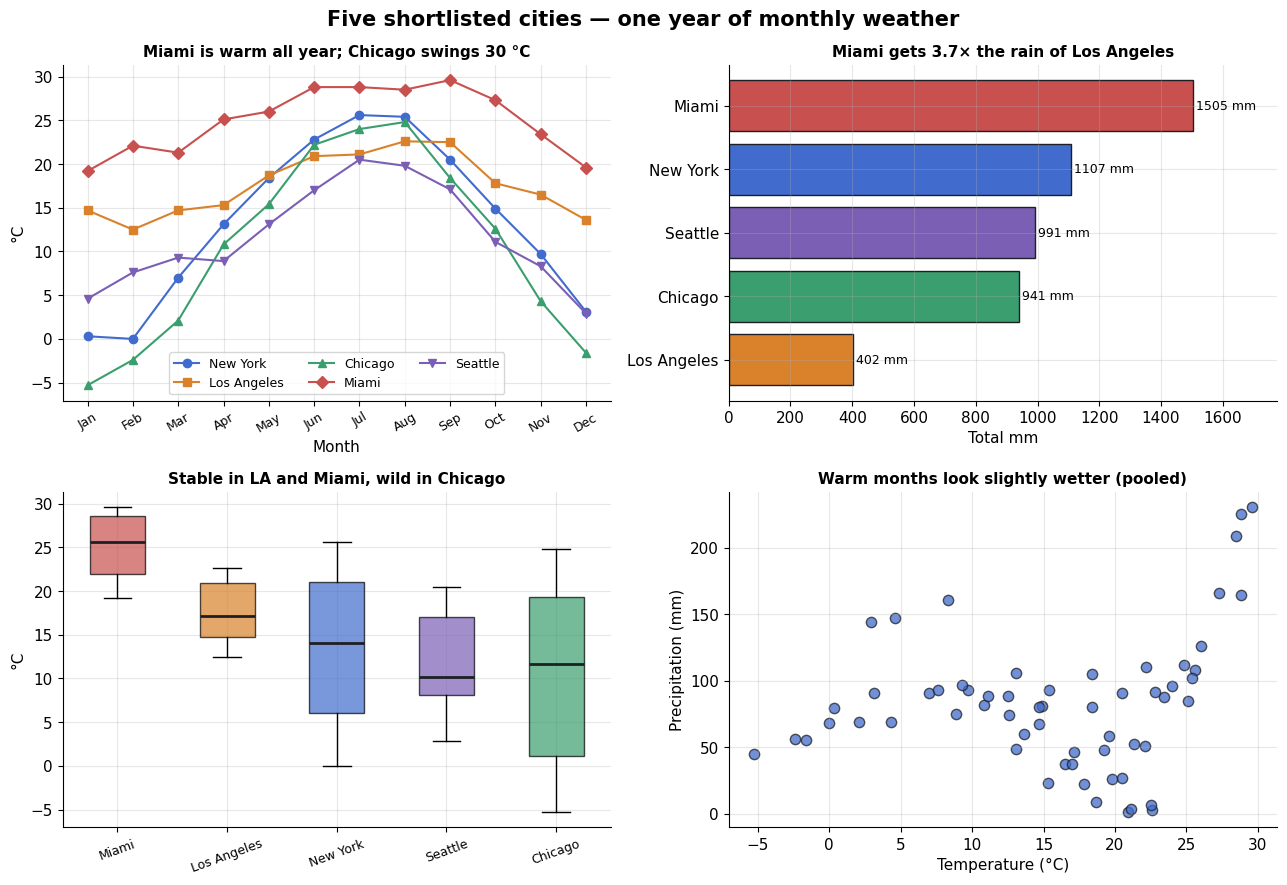

In [10]:
palette = {"New York": BAS_BLUE, "Los Angeles": BAS_AMBER,
           "Chicago": BAS_GREEN, "Miami": BAS_RED, "Seattle": BAS_PURPLE}
# one marker per city as well, so the curves stay readable without colour
markers = {"New York": "o", "Los Angeles": "s",
           "Chicago": "^", "Miami": "D", "Seattle": "v"}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Five shortlisted cities — one year of monthly weather",
             fontsize=15, fontweight="bold")

# (0, 0) Temperature curves per city
for city in cities:
    sub = df[df["city"] == city].sort_values("month_num")
    axes[0, 0].plot(sub["month_num"], sub["temperature"],
                    marker=markers[city], label=city, color=palette[city])
axes[0, 0].set_title("Miami is warm all year; Chicago swings 30 °C",
                     fontsize=11, fontweight="bold")
axes[0, 0].set_xlabel("Month")
axes[0, 0].set_ylabel("°C")
axes[0, 0].set_xticks(range(1, 13))
axes[0, 0].set_xticklabels(months, rotation=30, fontsize=9)
axes[0, 0].legend(fontsize=9, loc="lower center", ncol=3)

# (0, 1) Total annual precipitation per city
totals = df.groupby("city")["precipitation"].sum().sort_values()
bar_colors = [palette[c] for c in totals.index]
axes[0, 1].barh(totals.index, totals.values, color=bar_colors, edgecolor=BAS_INK)
for i, v in enumerate(totals.values):
    axes[0, 1].text(v + 10, i, f"{v:.0f} mm", va="center", fontsize=9)
axes[0, 1].set_title("Miami gets 3.7× the rain of Los Angeles",
                     fontsize=11, fontweight="bold")
axes[0, 1].set_xlabel("Total mm")
axes[0, 1].set_xlim(0, totals.max() * 1.18)

# (1, 0) Temperature distribution per city — box plot
city_order = list(by_city.index)             # warm → cold
box_data = [df.loc[df["city"] == c, "temperature"].values for c in city_order]
bp = axes[1, 0].boxplot(box_data, tick_labels=city_order, patch_artist=True,
                         medianprops=dict(color=BAS_INK, linewidth=2))
for patch, c in zip(bp["boxes"], city_order):
    patch.set_facecolor(palette[c]); patch.set_alpha(0.7)
axes[1, 0].set_title("Stable in LA and Miami, wild in Chicago",
                     fontsize=11, fontweight="bold")
axes[1, 0].set_ylabel("°C")
axes[1, 0].tick_params(axis="x", rotation=20, labelsize=9)

# (1, 1) Temperature vs precipitation — all 60 city-months pooled together
axes[1, 1].scatter(df["temperature"], df["precipitation"], s=55,
                   color=BAS_BLUE, edgecolor=BAS_INK, alpha=0.75)
axes[1, 1].set_title("Warm months look slightly wetter (pooled)",
                     fontsize=11, fontweight="bold")
axes[1, 1].set_xlabel("Temperature (°C)")
axes[1, 1].set_ylabel("Precipitation (mm)")

plt.tight_layout()
plt.show()

**Reading the dashboard against the brief.**

- **Top-left.** Miami never drops below ~19 °C; Chicago and New York have deep seasonal cycles, so *when* we go matters far more for them than for Los Angeles.
- **Top-right.** Miami takes 1 505 mm a year, Los Angeles 402 mm. That ratio, 3.7×, is the single most brief-relevant number on the page.
- **Bottom-left.** Box height is the annual range: Los Angeles and Miami are tight and predictable, Chicago is the widest by far. Predictability is worth money to an events team.
- **Bottom-right.** The pooled cloud of all 60 city-months. It slopes gently upward — warm months look a bit wetter. **Do not trust that yet.** Section 8 is about this panel, and it is not what it looks like.

## 8. A question worth getting wrong first

Ops sends a follow-up: *"If we pick a warm month, are we automatically picking a wet one?"* Fair question, and we have the two columns to answer it.

Here is the pooled answer over all 60 city-months. **Read it, then commit to an interpretation before you scroll.** Committing is the whole exercise: an insight you were handed is a fact you will forget by next week, while an insight that contradicts something you just claimed out loud is one you keep for good.

In [11]:
from sklearn.linear_model import LinearRegression

# Pooled Pearson correlation across every city and month
overall_corr = df["temperature"].corr(df["precipitation"])
print(f"Pooled correlation, all 60 city-months : r = {overall_corr:+.3f}")

# The same relationship as a one-feature linear model (notebooks 11 and 12)
pooled = LinearRegression().fit(df[["temperature"]], df["precipitation"])
print(f"Pooled linear fit  : precipitation = {pooled.intercept_:.1f} "
      f"{pooled.coef_[0]:+.2f} * temperature")
print(f"Pooled R^2         : {pooled.score(df[['temperature']], df['precipitation']):.3f}")

Pooled correlation, all 60 city-months : r = +0.219
Pooled linear fit  : precipitation = 62.8 +1.26 * temperature
Pooled R^2         : 0.048


### Commit before you scroll

Decide which of these you believe, and why:

- **(a)** Warmer months are wetter. The effect is weak but real: about **+1.3 mm of rain per °C**.
- **(b)** There is essentially **no relationship** between temperature and rainfall here.
- **(c)** The question is **not answerable** from this number.

Most readers take **(a)**: the sign is positive, the model fitted, the coefficient is +1.26 mm/°C. Some take **(b)**, pointing at R² = 0.048 — temperature accounts for under 5 % of the variation in rainfall, which is close enough to nothing.

Write your choice down. Then apply **step 6 of the notebook-10 checklist**, the step almost everyone skips: *is this number pooled over groups that differ?* Sixty rows. Five cities. Re-compute it inside each one.

In [12]:
print("The same two columns, one city at a time:\n")
for city, sub in df.groupby("city", sort=False):
    r = sub["temperature"].corr(sub["precipitation"])
    print(f"  {city:<12} n = {len(sub)}   r = {r:+.3f}")

The same two columns, one city at a time:

  New York     n = 12   r = +0.686
  Los Angeles  n = 12   r = -0.891
  Chicago      n = 12   r = +0.945
  Miami        n = 12   r = +0.934
  Seattle      n = 12   r = -0.898


### The reveal

| Subset | r |
|---|---|
| **Pooled, all 60 city-months** | **+0.22** |
| within Chicago | +0.95 |
| within Miami | +0.93 |
| within New York | +0.69 |
| within Los Angeles | **−0.89** |
| within Seattle | **−0.90** |

Every single city has a *strong* relationship — |r| between 0.69 and 0.95. The pooled figure is +0.22, which is to say: nearly nothing.

So **(c)** was the right answer, and both popular choices are wrong in an instructive way. **(a)** reports a real-looking effect of +1.26 mm/°C that describes **no city in the dataset**. **(b)** concludes "no relationship" from a table in which every group has a powerful one.

**Why it happens.** There are two climates in this table, not one.

- **Convective regime** (New York, Chicago, Miami): rain arrives *with* summer heat — thunderstorms, humidity, hurricane season. Slope positive.
- **Mediterranean regime** (Los Angeles, Seattle): the dry season *is* the warm season, and the rain comes with winter fronts. Slope negative.

Average two opposite strong relationships and you get a weak one. The pooled r is not mis-signed; it is **empty** — a number computed over a mixture nobody would defend if you said the mixture out loud.

> 🔗 **Not quite the trap from notebook 10.** The wine data there showed **Simpson's paradox** proper: the pooled correlation had the *wrong sign*, negative where every cultivar was positive. Here the pooled sign is not wrong, it is *meaningless* — the subgroups disagree with **each other** rather than with the aggregate. Same cause (a confounder: cultivar there, climate regime here), same cure (checklist step 6), different symptom. The sign-flipping version is the famous one; this version is far more common and hides much better, because a weak pooled correlation reads like an honest *"not much going on here"* rather than like a mistake.

Fit a line per city and the two regimes separate cleanly.

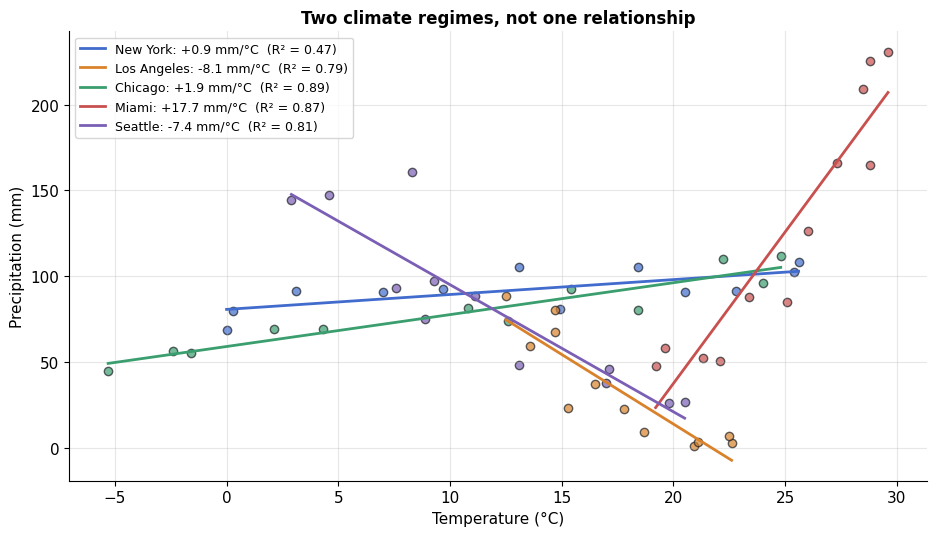

,slope_mm_per_C,r2,typical_miss_mm
city,,,
New York,0.87,0.47,9.07
Los Angeles,-8.11,0.79,15.39
Chicago,1.86,0.89,7.31
Miami,17.66,0.87,26.62
Seattle,-7.41,0.81,22.22


In [13]:
# One linear model per city: how much rain comes with each extra degree?
fits = []
fig, ax = plt.subplots(figsize=(9.5, 5.5))

for city in cities:
    sub = df[df["city"] == city]
    X, y = sub[["temperature"]].values, sub["precipitation"].values
    model = LinearRegression().fit(X, y)
    slope, r2 = float(model.coef_[0]), model.score(X, y)
    fits.append({
        "city":             city,
        "slope_mm_per_C":   slope,
        "r2":               r2,
        "typical_miss_mm":  float(np.std(y - model.predict(X), ddof=2)),
    })

    xs = np.linspace(X.min(), X.max(), 30).reshape(-1, 1)
    ax.scatter(X, y, color=palette[city], edgecolor=BAS_INK, alpha=0.7)
    ax.plot(xs, model.predict(xs), color=palette[city], linewidth=2,
            label=f"{city}: {slope:+.1f} mm/°C  (R² = {r2:.2f})")

ax.set_title("Two climate regimes, not one relationship",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Precipitation (mm)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

pd.DataFrame(fits).set_index("city").round(2)

### What the regression tells us — and what it does not

The numbers from the table above, sorted by slope:

| City | slope (mm per °C) | R² | typical miss |
|---|---|---|---|
| Miami | **+17.7** | 0.87 | ±27 mm |
| Chicago | +1.9 | 0.89 | ±7 mm |
| New York | +0.9 | 0.47 | ±9 mm |
| Seattle | **−7.4** | 0.81 | ±22 mm |
| Los Angeles | **−8.1** | 0.79 | ±15 mm |

**What it tells us.** Within a city, the sign and steepness of that line is a fingerprint of the climate regime — and it is exactly what the brief needs. Los Angeles's −8.1 mm/°C is *why* its July is bookable. Note too that steep is not the same as tight: Chicago has the best fit of the five (R² = 0.89) on a slope of only +1.9, while Miami's much steeper +17.7 still misses a typical month by ±27 mm.

**What it does not tell us.**

- **Nothing causal.** Warming Seattle by 1 °C would not remove 7.4 mm of rain. Both columns are driven by the same hidden variable — **the season** — which appears in the model not at all. This is a *description* of co-movement within a year, wearing the vocabulary of prediction.
- **Twelve points per line.** Each fit has n = 12 and two parameters. Drop one month and the slopes move. Do not quote them to two decimals in front of a meteorologist.
- **No extrapolation.** New York's line was fitted between 0 °C and 26 °C. Asking it about 35 °C is asking it about weather it has never seen.
- **Not the right model anyway.** Rainfall depends on month, latitude, ocean proximity and storm tracks. A one-feature line is a summary, not a mechanism.

That last point is the honest version of a sentence you will hear a great deal: *the model fits, therefore the story is true.* These models fit because both variables ride the same calendar.

## 9. Bonus — which cities are climate twins?

A side question with a real use: if the recommended city falls through, which of the others is the closest substitute? Build a small distance matrix from each city's monthly temperature profile.

In [14]:
# Pivot to a city × month matrix
profiles = df.pivot_table(index="city", columns="month_num", values="temperature")
# Standardise each city so we compare *shape*, not absolute level (optional)
# profiles = (profiles.subtract(profiles.mean(axis=1), axis=0))

# Euclidean distance between every pair of cities
from itertools import combinations
distances = pd.DataFrame(index=cities, columns=cities, dtype=float)
for a, b in combinations(cities, 2):
    d = float(np.linalg.norm(profiles.loc[a].values - profiles.loc[b].values))
    distances.loc[a, b] = d
    distances.loc[b, a] = d
distances = distances.fillna(0).round(1)

print("Pairwise distance of monthly temperature profiles (lower = more similar):")
print(distances)

Pairwise distance of monthly temperature profiles (lower = more similar):
             New York  Los Angeles  Chicago  Miami  Seattle
New York          0.0         25.1     11.8   44.8     15.7
Los Angeles      25.1          0.0     35.4   26.2     22.5
Chicago          11.8         35.4      0.0   55.9     19.1
Miami            44.8         26.2     55.9    0.0     47.0
Seattle          15.7         22.5     19.1   47.0      0.0


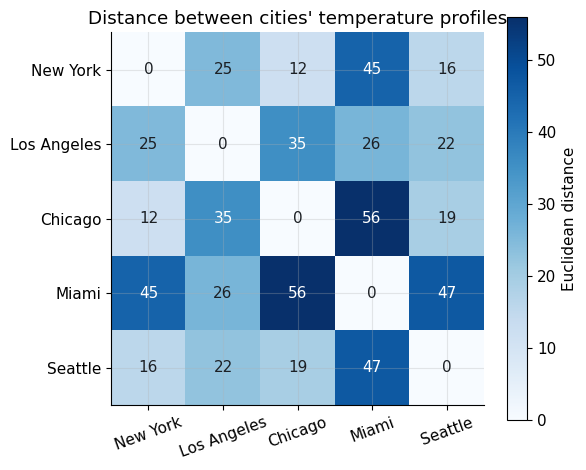

In [15]:
# Heatmap of the similarity matrix
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(distances.values, cmap="Blues")
ax.set_xticks(range(len(cities)), cities, rotation=20)
ax.set_yticks(range(len(cities)), cities)
for i in range(len(cities)):
    for j in range(len(cities)):
        ax.text(j, i, f"{distances.iloc[i, j]:.0f}", ha="center", va="center",
                color="white" if distances.iloc[i, j] > distances.values.max()/2 else BAS_INK)
ax.set_title("Distance between cities' temperature profiles")
fig.colorbar(im, ax=ax, label="Euclidean distance")
plt.tight_layout()
plt.show()

Chicago and New York are the closest pair (distance **11.8**) — genuine climate twins. The outlier is **Miami**: its mean distance to the other four is **43.5**, against Los Angeles's **27.3**, and the most dissimilar pair in the whole table is Miami–Chicago at **55.9**.

Now the caveat, which is the actual lesson. This matrix is built from **temperature only**, so Los Angeles and Seattle come out fairly close (**22.5**) even though one of them receives 402 mm of rain a year and the other 991 mm. A distance matrix answers exactly the question you fed it and no other. Feed it rainfall as well, or standardise each profile first (the commented-out line above) to compare *shape* rather than level, and the ranking changes. Whenever you report a similarity, report what it was measured on.

You could plug this same matrix into a clustering algorithm — that is how grouping by climate type actually works in practice.

## 10. Answering the brief

Nine sections of analysis, and the deliverable is still a single sentence: *which city, in July?*

Time to turn the two constraints into code. Note what changes here: up to now we have been asking the data questions. Now we apply somebody else's requirements, as written, without negotiation. Beginners skip this step and present the analysis instead; it is the step the client was paying for.

In [16]:
# The two hard constraints from the brief, as code
TEMP_MIN, TEMP_MAX, RAIN_MAX = 18, 27, 90

df["meets_brief"] = (df["temperature"].between(TEMP_MIN, TEMP_MAX)
                     & (df["precipitation"] < RAIN_MAX))

print(f"City-months meeting both constraints: {df['meets_brief'].sum()} of {len(df)}\n")
print("Qualifying months per city (any month of the year):")
print(df.groupby("city")["meets_brief"].sum().sort_values(ascending=False).to_string())

# ... but the school is in July, so only one row per city can decide it
july = df[df["month"] == "Jul"].sort_values("precipitation")
print("\nJuly — the month Ops asked about:")
print(july[["city", "temperature", "precipitation", "meets_brief"]].to_string(index=False))

City-months meeting both constraints: 14 of 60

Qualifying months per city (any month of the year):
city
Miami          6
Los Angeles    5
Seattle        2
Chicago        1
New York       0

July — the month Ops asked about:
       city  temperature  precipitation  meets_brief
Los Angeles         21.1            3.5         True
    Seattle         20.5           26.7         True
    Chicago         24.0           95.9        False
   New York         25.6          108.2        False
      Miami         28.8          164.8        False


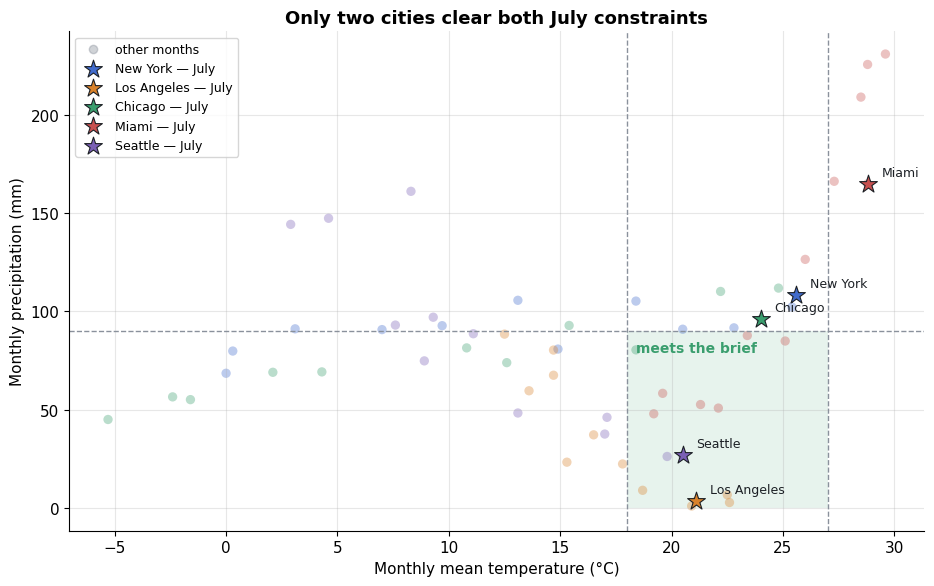

In [17]:
# The decision chart: every city-month, the acceptable region, and July highlighted
fig, ax = plt.subplots(figsize=(9.5, 6))

ax.add_patch(plt.Rectangle((TEMP_MIN, 0), TEMP_MAX - TEMP_MIN, RAIN_MAX,
                           facecolor=BAS_GREEN, alpha=0.12, zorder=0))
ax.text(TEMP_MIN + 0.4, RAIN_MAX - 5, "meets the brief", color=BAS_GREEN,
        fontsize=10, fontweight="bold", va="top")

ax.scatter([], [], color=BAS_GREY, alpha=0.4, label="other months")
for city in cities:
    sub = df[df["city"] == city]
    ax.scatter(sub["temperature"], sub["precipitation"], s=45, alpha=0.35,
               color=palette[city], edgecolor="none")
    jul = sub[sub["month"] == "Jul"]
    ax.scatter(jul["temperature"], jul["precipitation"], s=180, marker="*",
               color=palette[city], edgecolor=BAS_INK, linewidth=0.8, zorder=5,
               label=f"{city} — July")
    ax.annotate(city, (float(jul["temperature"].iloc[0]),
                       float(jul["precipitation"].iloc[0])),
                textcoords="offset points", xytext=(10, 6), fontsize=9, color=BAS_INK)

for x in (TEMP_MIN, TEMP_MAX):
    ax.axvline(x, color=BAS_GREY, linestyle="--", linewidth=1)
ax.axhline(RAIN_MAX, color=BAS_GREY, linestyle="--", linewidth=1)

ax.set_title("Only two cities clear both July constraints",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Monthly mean temperature (°C)")
ax.set_ylabel("Monthly precipitation (mm)")
ax.legend(fontsize=9, loc="upper left")
plt.tight_layout()
plt.show()

### The recommendation

**Los Angeles, July.** A mean of 21.1 °C sits comfortably inside the 18–27 °C window, and 3.5 mm of rain leaves over 86 mm of margin on a 90 mm limit. **Seattle (20.5 °C, 26.7 mm) is a viable fallback.** The other three fail, all of them on rain: Chicago 95.9 mm, New York 108.2 mm, Miami 164.8 mm — and Miami also breaches the temperature ceiling at 28.8 °C.

Three things are worth noticing about that answer.

1. **The boring city won.** Section 5 filed Los Angeles as the least interesting of the five: smallest temperature range, least rain, no dramatic season. Those are not boring properties to an operations team — they are the entire product. The most analytically *interesting* city, Miami, is unbookable.
2. **The confounding detour paid for itself.** Los Angeles and Seattle clear the brief for the same structural reason: they are the two cities whose temperature–rainfall slope is **negative**. In a Mediterranean climate the warm season *is* the dry season. That was not a side-quest we took to show off — it is the mechanism behind the recommendation, and it is why we would expect the answer to hold in a year we have not seen.
3. **One constraint did all the work.** Four of the five cities are inside the temperature window in July; rain eliminated three of them. So if Ops can relax the 90 mm limit — a marquee, a credible indoor plan B — the shortlist reopens, and Chicago at 95.9 mm is the first city back in. Which constraint is *binding* is far more actionable than the ranking, so say it out loud.

**What this analysis cannot tell them** — and the summary must include this:

- **The data is simulated.** Realistic monthly climatology plus noise, not measurements. A real decision needs 20–30 years of NOAA station records.
- **One year, monthly means.** No heatwaves, no storm risk (for Miami in the real world, hurricane season is the actual objection), and no information about how the rain is distributed *within* a month.
- **Weather is not the decision.** Venue cost, flight connections, visas and accommodation are absent entirely, and any one of them can outrank a rainfall column.

> 💾 To hand the table over with the report, `df.to_csv("weather_report.csv", index=False)` writes it out; reading it straight back with `pd.read_csv` and checking `.shape` is the cheap way to confirm nothing was lost.

## 11. Your deliverable

### Exercise 14.1 — Write the executive summary

Everything above is *your working*. None of it is what Ops asked for. Now write the thing they asked for.

**The spec, taken literally from the brief:**

| | |
|---|---|
| **Audience** | the Operations lead. Not a data scientist. Reads it on a phone, once, and forwards it to the director without editing. |
| **Length** | **five bullets**, one sentence each, **≤ 25 words**. |
| **Job** | let them act — book a city — without ever opening this notebook. |

**A structure that works.** Use it in this order:

1. **The recommendation.** Lead with the answer, not the method. Not *"we analysed 60 city-months"* but *"Recommend Los Angeles for July."*
2. **The evidence.** The two or three numbers that carry the case, with units.
3. **The runner-up.** Decision-makers need an alternative, and it costs you one line.
4. **The binding constraint.** What would change the answer. This is the bullet that gets you invited to the next project.
5. **The limit.** What the data cannot support — stated plainly, not hedged into mush.

**What separates a good summary from a bad one**

- **Lead with the finding.** Your method is not news. Nobody was waiting to hear about `groupby`.
- **Quantify everything.** "Much drier" is an opinion; "3.5 mm versus 108 mm" is a fact.
- **State the limit once, clearly, and early enough to matter.** A caveat in the footnotes is not a caveat.
- **No buzzwords and no methods jargon.** No "leveraged", no "robust", no "R²", no "Simpson's paradox". The confounding shaped your analysis; it is not the executive's problem.
- **Say what you would need in order to be sure.** One line — and it is how you get budget for real data.

> 🔗 **Different from the notebook-10 write-up.** There you wrote for yourself and your colleagues: *what we learned / what to check next / what this data cannot tell us*. This one is written for someone who will never read the analysis and must act anyway. Same honesty, a tenth of the words, and the answer first instead of last.

Draft yours below, then expand the solution to compare.

In [18]:
# Your five bullets  👇  one sentence each, <= 25 words, numbers with units
summary = """
1. Recommendation:
2. Evidence:
3. Runner-up:
4. What would change the answer:
5. What this data cannot tell you:
"""
print(summary)

# A crude but genuinely useful self-check: are the bullets actually short?
print("Length check (the brief said one sentence, 25 words maximum):")
for line in summary.strip().splitlines():
    n_words = len(line.split()) - 1          # minus the "1." marker
    verdict = "ok" if n_words <= 25 else "TOO LONG"
    print(f"  {n_words:3d} words  {verdict:8s} | {line[:58]}")


1. Recommendation:
2. Evidence:
3. Runner-up:
4. What would change the answer:
5. What this data cannot tell you:

Length check (the brief said one sentence, 25 words maximum):
    1 words  ok       | 1. Recommendation:
    1 words  ok       | 2. Evidence:
    1 words  ok       | 3. Runner-up:
    5 words  ok       | 4. What would change the answer:
    6 words  ok       | 5. What this data cannot tell you:


<details>
<summary>💡 Click to reveal the solution</summary>

```
1. Recommendation: hold the July school in Los Angeles — 21 °C mean, 3.5 mm rain, both venue constraints met with margin.
2. Evidence: LA is the driest shortlisted city (402 mm/year against Miami's 1 505 mm) and the most temperature-stable (10 °C annual range).
3. Runner-up: Seattle in July (20.5 °C, 27 mm) also qualifies; New York, Chicago and Miami all fail the 90 mm rainfall limit.
4. Binding constraint is rainfall, not heat: relax the 90 mm limit to 100 mm and Chicago (96 mm) returns to the shortlist.
5. Limit: one simulated year of monthly averages, so no heatwaves, storms or within-month timing — confirm against 20 years of records.
```

**Why these five work.** Bullet 1 is the decision, inside the first six words: if the reader stops there, they still have exactly what they asked for. Bullets 2 and 3 carry the numbers and the alternative, so nobody has to come back and ask "compared to what?". Bullet 4 is the one analysts habitually omit and managers always need — it names *which* constraint is doing the work, which is the only lever they actually control. Bullet 5 is the honesty, and note that it is **specific**: "one simulated year of monthly averages" plus a named remedy, rather than the useless generic "further research is needed".

Note what is *absent*: no `groupby`, no pooled correlation, no Simpson's paradox, no R². The confounding detour changed the analysis completely and belongs in your working notes — it earns no words here. Deciding what not to send is part of the deliverable.
</details>

## 12. More practice

### Exercise 14.2 — Add a "comfort index"

Ops pushes back: *"two hard thresholds are crude — can you give us a single score instead?"*

Build a column `comfort_index = temperature - 0.1 * precipitation - 0.05 * humidity + 0.05 * wind`, then find the *most comfortable* month for each city according to that index. Afterwards, look at the answer for Miami and ask yourself whether a single score is really an improvement on two honest thresholds.

In [19]:
# Your code here  👇


<details>
<summary>💡 Click to reveal the solution</summary>

```python
df["comfort_index"] = (df["temperature"]
                       - 0.1 * df["precipitation"]
                       - 0.05 * df["humidity"]
                       + 0.05 * df["wind"])

best = (df.loc[df.groupby("city")["comfort_index"].idxmax(),
               ["city", "month", "comfort_index"]]
        .set_index("city"))
print(best.round(2))
```

*Why this works:* `idxmax` inside each group returns the row **label** of the best month, which `.loc` then uses to pull the whole row — the same pattern we used for the wettest month in Section 6.

*And the catch:* the index picks **August for Los Angeles (20.0)** and **February for Miami (14.9)** — February, because Miami's winter is dry and the rainfall penalty dominates. That is a defensible answer to a different question, and it is useless for this brief, which is about **July**. Worse, the weights (0.1, 0.05, 0.05) were invented by whoever wrote the formula: change them and the ranking changes, with no data to appeal to. A single composite score hides its assumptions inside one number; two stated thresholds keep them where the client can argue with them. Prefer the version your client can push back on.
</details>

### Exercise 14.3 — How fragile is your recommendation?

Your whole answer rests on **one** simulated year. `make_weather()` takes a `seed`, so other years are cheap.

Regenerate the dataset with seeds 7, 123 and 2024. For each one, print which cities pass **both** July constraints. Does the recommendation survive? Which city's verdict comes closest to flipping — and is it close because of the noise, or because of where the line was drawn?

In [20]:
# Your code here  👇


<details>
<summary>💡 Click to reveal the solution</summary>

```python
for seed in (7, 123, 2024):
    alt = make_weather(seed=seed)
    jul = alt[alt["month"] == "Jul"].copy()
    jul["passes"] = (jul["temperature"].between(18, 27)
                     & (jul["precipitation"] < 90))
    print(f"seed {seed:>4} -> passes: {list(jul.loc[jul['passes'], 'city'])}")
    print(jul[["city", "temperature", "precipitation", "passes"]].to_string(index=False))
    print()
```

Output:

```
seed    7 -> passes: ['Los Angeles', 'Seattle']
seed  123 -> passes: ['Los Angeles', 'Seattle']
seed 2024 -> passes: ['Los Angeles', 'Seattle']
```

*Why this works, and what it means.* The recommendation is **stable**: Los Angeles and Seattle pass in every year, and the reason is structural rather than lucky — both are Mediterranean-regime cities whose dry season coincides with the school.

The interesting city is **Chicago**, whose July rainfall lands at 92.0, 93.7 and 95.1 mm across the three seeds. It fails every time, but by 2–5 mm. That is not noise sensitivity, it is **threshold sensitivity**: Chicago's verdict is decided by where Ops drew the 90 mm line, not by randomness in the data. Reporting it that way turns a borderline number into an actionable one — exactly bullet 4 of the executive summary.

And the honest limit of this exercise: re-running your own simulator tests **the noise you added**, not whether the underlying climatology is right. A stable answer across seeds is not evidence about the real world. Only real data can give you that.
</details>

### Exercise 14.4 — Try a different prediction problem

Train a `RandomForestRegressor` to predict **precipitation** from `temperature`, `humidity`, `wind` and one-hot encoded `city`. Use an 80/20 split and report MAE and R². Then compare the model against the dumbest possible baseline — always predicting the mean of the training set — and decide whether it earned its complexity.

In [21]:
# Your code here  👇


<details>
<summary>💡 Click to reveal the solution</summary>

```python
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

X = pd.get_dummies(df[["temperature", "humidity", "wind", "city"]],
                   columns=["city"], drop_first=False)
y = df["precipitation"].values

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)
rf = RandomForestRegressor(n_estimators=200, random_state=42).fit(Xtr, ytr)
yhat = rf.predict(Xte)

print(f"Random forest  MAE : {mean_absolute_error(yte, yhat):.2f} mm")
print(f"Random forest  R²  : {r2_score(yte, yhat):.3f}")

baseline = np.full_like(yte, ytr.mean())
print(f"Predict-the-mean MAE : {mean_absolute_error(yte, baseline):.2f} mm")
```

Output:

```
Random forest  MAE : 24.50 mm
Random forest  R²  : 0.211
Predict-the-mean MAE : 24.74 mm
```

*Why this works:* one-hot encoding turns the categorical `city` column into five 0/1 columns a tree model can split on, and the split → fit → predict → evaluate-on-unseen-data sequence is the notebook-12 workflow.

*And now read the numbers honestly.* R² = 0.21 sounds like a modest success. The MAE says otherwise: **24.50 mm against a predict-the-mean baseline of 24.74 mm.** Two hundred trees bought us a quarter of a millimetre. With 48 training rows and 12 test rows there simply is not enough data for a flexible model to find anything — and the per-city linear fits in Section 8, with two parameters each, described the same data far better (R² 0.47–0.89). **Always compute the dumb baseline.** A metric with nothing to compare it against cannot tell you whether a model is good, and "R² = 0.21" would have gone into a slide deck unchallenged.
</details>

### Exercise 14.5 — Debug me 🐞

The cell below is meant to print the five **hottest** (city, month) rows and each city's **total annual precipitation**. It runs without any error — but both outputs are wrong. Find and fix the two bugs.

In [22]:
# Five hottest city-months ... or are they?
print(df.sort_values("temperature")[["city", "month", "temperature"]].head())

# Total annual precipitation per city ... or is it?
print()
print(df.groupby("city")["precipitation"].mean())


        city month  temperature
24   Chicago   Jan         -5.3
25   Chicago   Feb         -2.4
35   Chicago   Dec         -1.6
1   New York   Feb          0.0
0   New York   Jan          0.3

city
Chicago         78.425000
Los Angeles     33.475000
Miami          125.391667
New York        92.275000
Seattle         82.566667
Name: precipitation, dtype: float64


<details>
<summary>💡 Click to reveal the solution</summary>

Two silent bugs — the worst kind, because nothing crashes:

1. `sort_values` sorts **ascending** by default, so `.head()` returns the five *coldest* rows. Pass `ascending=False`.
2. `.mean()` computes the average *monthly* precipitation, not the annual *total*. Use `.sum()`.

```python
# Five hottest city-months
print(df.sort_values("temperature", ascending=False)[["city", "month", "temperature"]].head())

# Total annual precipitation per city
print()
print(df.groupby("city")["precipitation"].sum())
```

Now Miami's June-to-October run fills the temperature list, and the totals match the dashboard's annual-precipitation panel (Miami ≈ 1 505 mm, Los Angeles ≈ 402 mm). **Lesson:** code that runs is not the same as code that is right — always sanity-check an output against something you already know. Both of these bugs would have survived any test that only checked "did it produce five rows and five numbers".
</details>

## 🧠 Key takeaways

1. **A project starts with a question, not a dataset.** The brief decided which statistic mattered (July, not the annual mean), which chart was worth drawing, and when to stop analysing.
2. **Audit before you analyse.** Duplicates, impossible values and grain ("what is one row?") cost five minutes here and save whole conclusions later.
3. **Re-check every aggregate inside its groups.** A pooled +0.22 hid five relationships between −0.90 and +0.95. Notebook 10's checklist step 6 is the highest-value line in the whole workflow.
4. **`groupby`, `pivot_table` and boolean filtering are 80 % of pandas work** — and a filter that encodes someone else's constraints is what turns analysis into a decision.
5. **Give every panel a claim, not a topic.** A dashboard whose titles state findings does the reader's work for them.
6. **A model that fits is not a story that is true.** Both of our columns ride the same calendar; a good R² inside a city is a fact about seasonality, not evidence that heat makes rain. Always compute the dumb baseline too.
7. **State the limits, and state which constraint is binding.** Those two sentences are what a client can act on, and they are what distinguishes an analyst from a plotting library.

## ✅ Self-assessment

Before you close the notebook, check that you can:

- [ ] Turn a written brief into concrete, testable constraints on a DataFrame
- [ ] Audit a fresh table for duplicates, missing values, impossible values and grain
- [ ] Summarise groups with `groupby().agg()` and reshape data with `pivot_table`
- [ ] Engineer categorical features with a helper function and `apply`
- [ ] Assemble a multi-panel matplotlib dashboard whose panel titles state findings
- [ ] Explain how strong per-group relationships can average out into a meaningless aggregate — and how that differs from a sign-flipping Simpson's paradox
- [ ] Fit a `LinearRegression` per group, read slope, R² and typical error, and refuse the causal claim
- [ ] Compare any model against a predict-the-mean baseline before believing it
- [ ] Write a five-bullet executive summary that leads with the finding, quantifies it, and states the limit

## 🎓 Congratulations — you have finished the course!

You have completed all **fourteen** notebooks of the Advanced & Self-Learning Track — from your first variables (01) through control flow and collections (02–04), functions and modules (05), NumPy and pandas (06–07), data cleaning and preprocessing (08), visualisation (09), exploratory data analysis (10), the concepts of machine learning (11), the professional scikit-learn workflow (12), PyTorch tensors and a training loop you wrote by hand (13), and now a full end-to-end project that ends in a decision someone could act on. That is a genuine achievement. 🎉

And notice what the finale did *not* need: no deep learning, no ensemble, no tuning. Sixty rows, a handful of `groupby` calls, five straight lines and one question asked in the right order. Most of the value you will ever add looks like that. The advanced tools are for when the problem earns them.

**Where to go next:**

- **Bridging AI & Society Summer Schools.** This course is part of the [Bridging AI & Society Summer Schools](https://github.com/BridgingAISocietySummerSchools) organisation. A natural next step is the [Hands-On-Notebooks](https://github.com/BridgingAISocietySummerSchools/Hands-On-Notebooks) repository, which continues into machine-learning topics in the same hands-on style.
- **Real datasets.** Try Kaggle's [Titanic](https://www.kaggle.com/c/titanic), [House Prices](https://www.kaggle.com/c/house-prices-advanced-regression-techniques), or the [UCI ML Repository](https://archive.ics.uci.edu/). Better still: find a table about something you already care about, and write it a brief of your own.
- **Deeper ML.** Building on notebook 12: regularisation (Ridge / Lasso), gradient boosting (XGBoost, LightGBM), and model interpretation beyond feature importance (SHAP, partial dependence).
- **Deep learning.** You wrote your first training loop in notebook 13 — next come convolutional networks for images, transformers for text, and sequence models for time series.
- **Deployment.** Wrap your model into an API with FastAPI or Streamlit.
- **Storytelling.** Keep practising the five bullets. Communication is not the wrapping on the analysis; it is half the value.
- **Revisit anything.** The track stays here for you: back one step to [`13_pytorch_basics.ipynb`](13_pytorch_basics.ipynb), back to the workflow in [`12_scikit_learn_workflow.ipynb`](12_scikit_learn_workflow.ipynb), or right to the beginning at [`01_python_basics.ipynb`](01_python_basics.ipynb).

> *"The best way to learn data science is to do data science."*